# Matching and comparison of the database with EM-DAT 

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
import pandas as pd
import ast
import geopandas as gpd

from src.LLM_functions import *
from src.plot_functions import *
from src.data import *
from src.post_process_functions import *
from src.hazard_def import *
from src.external_comparaison import *

#sys.path.append('/home/lhasbini/como_school/como_project4/src/')

In [4]:
# Import extracted impact
df_llm = pd.read_csv(DATA_PATH + 'results_proc/'+'post_processed_llm_response_impact_labelled_reports_test_continue_16rep_meta-llama_llama-4-scout-17b-16e-instruct.csv', encoding='utf-8')
df_llm_geo = gpd.read_file(DATA_PATH + 'results_proc/'+'post_processed_llm_response_impact_labelled_reports_test_continue_16rep_meta-llama_llama-4-scout-17b-16e-instruct_geo.gpkg')

#Manually labelled 
df_labelled_geo = gpd.read_file(DATA_PATH + 'results_proc/'+'post_processed_labelled_reports_impacts_all_geo.gpkg')

#Conver columns to list 
col_to_list = ['country', 'location', 'hazards', 'locationOsm', 'locationGaul']
for col in col_to_list : 
        # df_llm[col] = df_llm[col].apply(
        #     lambda x: ast.literal_eval(x) if pd.notna(x) and isinstance(x, str) and x.strip().startswith("[") else ([x] if pd.notna(x) else None)
        # )
        df_llm_geo[col] = df_llm_geo[col].apply(
            lambda x: ast.literal_eval(x) if pd.notna(x) and isinstance(x, str) and x.strip().startswith("[") else ([x] if pd.notna(x) else None)
        )
        df_labelled_geo[col] = df_labelled_geo[col].apply(
            lambda x: ast.literal_eval(x) if pd.notna(x) and isinstance(x, str) and x.strip().startswith("[") else ([x] if pd.notna(x) else None)
        )

In [5]:
df_llm_geo_grp = clean_group(df_llm_geo)
df_labelled_geo_grp = clean_group(df_labelled_geo)

In [17]:
# Import data from other sources 
df_ifrc_go = open_clean_ifrc_go()
df_ifrc_monty = open_clean_ifrc_monty(df_ifrc_go)

In [44]:
df_ifrc_monty.head()

,Unnamed: 0,geometry,roles,title,datetime,description,end_datetime,monty:etl_id,monty:corr_id,start_datetime,monty:hazard_codes,monty:country_codes,monty:episode_number,id,impact_type,impact_value,impact_category,impact_estimate_type,appealCode
0,0,POLYGON ((18.624960000000044 3.479440000000068...,"source, impact",COG: Epidemic - 07-2025 - CHOLERA EPIDEMIC,2025-07-26 00:00:00+00:00,This confirmation of the cholera epidemic in o...,2025-07-26T00:00:00Z,86cf0369-9b4a-486e-a159-1352dac5e8c7,20250726-COG-NAT-BIO-EPI-DIS-1-GCDB,2025-07-26T00:00:00Z,nat-bio-epi-dis,COG,1,ifrcevent-impact--7581-assisted,assisted,2000000,people,primary,MDRCG025
1,1,MULTIPOLYGON (((-75.28583999999995 -0.11971999...,"source, impact",ECU: Epidemic - 04-2025 - Yellow Fever,2025-04-17 00:00:00+00:00,"On April 24, 2025, the Ministry of Health conf...",2025-04-17T00:00:00+00:00,8af74cfb-ddd6-4b18-b097-7436487383e6,20250417-ECU-NAT-BIO-EPI-DIS-1-GCDB,2025-04-17T00:00:00+00:00,nat-bio-epi-dis,ECU,1,ifrcevent-impact--7485-assisted,assisted,1,people,primary,MDREC028
2,2,POLYGON ((27.455280000000073 5.016390000000058...,"source, impact",COD: Flood - 04-2025 - Floods in the city of K...,2025-04-11 00:00:00+00:00,"<p class=""MsoNormal"" style=""text-align: justif...",2025-04-11T00:00:00+00:00,5c0a04bd-a447-40d2-9f85-ae5ca1414abd,20250411-COD-NAT-HYD-FLO-FLO-1-GCDB,2025-04-11T00:00:00+00:00,FL,COD,1,ifrcevent-impact--7475-injured,Injured People,28,people,primary,MDRCD046
3,3,POLYGON ((27.455280000000073 5.016390000000058...,"source, impact",COD: Flood - 04-2025 - Floods in the city of K...,2025-04-11 00:00:00+00:00,"<p class=""MsoNormal"" style=""text-align: justif...",2025-04-11T00:00:00+00:00,4130c5c4-e82d-4a4f-9241-c403a908bba2,20250411-COD-NAT-HYD-FLO-FLO-1-GCDB,2025-04-11T00:00:00+00:00,FL,COD,1,ifrcevent-impact--7475-displaced_total,Displaced People,7025,people,primary,MDRCD046
4,4,POLYGON ((27.455280000000073 5.016390000000058...,"source, impact",COD: Flood - 04-2025 - Floods in the city of K...,2025-04-11 00:00:00+00:00,"<p class=""MsoNormal"" style=""text-align: justif...",2025-04-11T00:00:00+00:00,ba67afe9-1976-446a-889e-e4bf013c0e97,20250411-COD-NAT-HYD-FLO-FLO-1-GCDB,2025-04-11T00:00:00+00:00,FL,COD,1,ifrcevent-impact--7475-death,Human Deaths,165,people,primary,MDRCD046


In [45]:
df_ifrc_go.head()

,Affected People,Affected People Source,Displaced People,Displaced People Source,Human Deaths,Human Deaths Source,Infected and Ill People,Infected and Ill People Source,Injured People,Injured People Source,...,name,num_affected,parent_event,slug,summary,tab_one_title,tab_three_title,tab_two_title,translation_module_original_language,updated_at
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,TZA: Civil Unrest - 10-2025 - TANZANIA GENERAL...,NaN,NaN,NaN,General elections in Tanzania are scheduled fo...,Additional Information,NaN,NaN,en,2025-08-06T08:11:56.241026Z
1,150000.0,other,NaN,NaN,NaN,NaN,NaN,NaN,3.0,other,...,DJI: Population Movement - 10-2025 - Return of...,NaN,NaN,NaN,"<p class=""MsoNormal"" style=""text-align: justif...",Additional Information,NaN,NaN,en,2025-05-15T16:48:44.417133Z
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,BHS: Cyclone - 08-2025 - Hurricane Erin,NaN,NaN,NaN,NaN,Additional Information,NaN,NaN,en,2025-08-18T20:04:31.509504Z
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,Mauritania Population Movement 2025,NaN,NaN,NaN,"Since January 2025, the MRC has reported a gro...",Additional Information,NaN,NaN,en,2025-08-13T07:52:22.449907Z
4,NaN,NaN,NaN,NaN,1.0,gov,NaN,NaN,52.0,gov,...,TUR: Earthquake - 08-2025 - Sındırgı Earthquake,NaN,NaN,NaN,<p>The Earthquake with a magnitude of 6.1 stru...,Additional Information,NaN,NaN,en,2025-08-10T22:47:07.521391Z


In [20]:
from matplotlib.ticker import ScalarFormatter
def plot_affected_people(df_llm_geo_grp, df_labelled_geo_grp, df_impact_ifrc_monty_appeal, df_go_subset, appealCodelist, impactType):
    # --- Prepare each source ---
    df1 = (
        df_llm_geo_grp[(df_llm_geo_grp["impactSubtype"] == impactType) & 
                       (df_llm_geo_grp["appealCode"].isin(appealCodelist))]
        [["appealCode", "impactValue_final"]]
        .groupby("appealCode", as_index=False)
        .sum()
        .rename(columns={"impactValue_final": "LLM_extracted"})
    )

    df2 = (
        df_labelled_geo_grp[(df_labelled_geo_grp["impactSubtype"] == impactType) & 
                       (df_labelled_geo_grp["appealCode"].isin(appealCodelist))]
        [["appealCode", "impactValue_final"]]
        .groupby("appealCode", as_index=False)
        .sum()
        .rename(columns={"impactValue_final": "Manual_labelling"})
    )

    df3 = (
        df_impact_ifrc_monty_appeal[(df_impact_ifrc_monty_appeal["impact_type"] == impactType)& 
                                    (df_impact_ifrc_monty_appeal["appealCode"].isin(appealCodelist))]
        [["appealCode", "impact_value"]]
        .groupby("appealCode", as_index=False)
        .sum()
        .rename(columns={"impact_value": "IFRC_Monty"})
    )

    df4 = df_go_subset[["appealCode", impactType]].loc[df_go_subset["appealCode"].isin(appealCodelist)].rename(
        columns={impactType : "IFRC_GO"}
    )

    # --- Merge all together ---
    df_all = df1.merge(df2, on="appealCode", how="outer").merge(df3, on="appealCode", how="outer").merge(df4, on="appealCode", how="outer")

    # --- Plot ---
    ax = df_all.set_index("appealCode").plot(
        kind="bar", figsize=(12, 6), width=0.8, logy=True
    )

    # Format y-axis to switch to scientific notation for large values
    formatter = ScalarFormatter(useMathText=True)
    formatter.set_scientific(True)
    formatter.set_powerlimits((-3, 3))  # auto switch if values <1e-3 or >1e3
    ax.yaxis.set_major_formatter(formatter)
    
    plt.title(f"Number of {impactType} by Appeal Code (Comparison of Sources)")
    plt.xlabel("Appeal Code")
    plt.ylabel("Number of Affected People")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

    return df_all


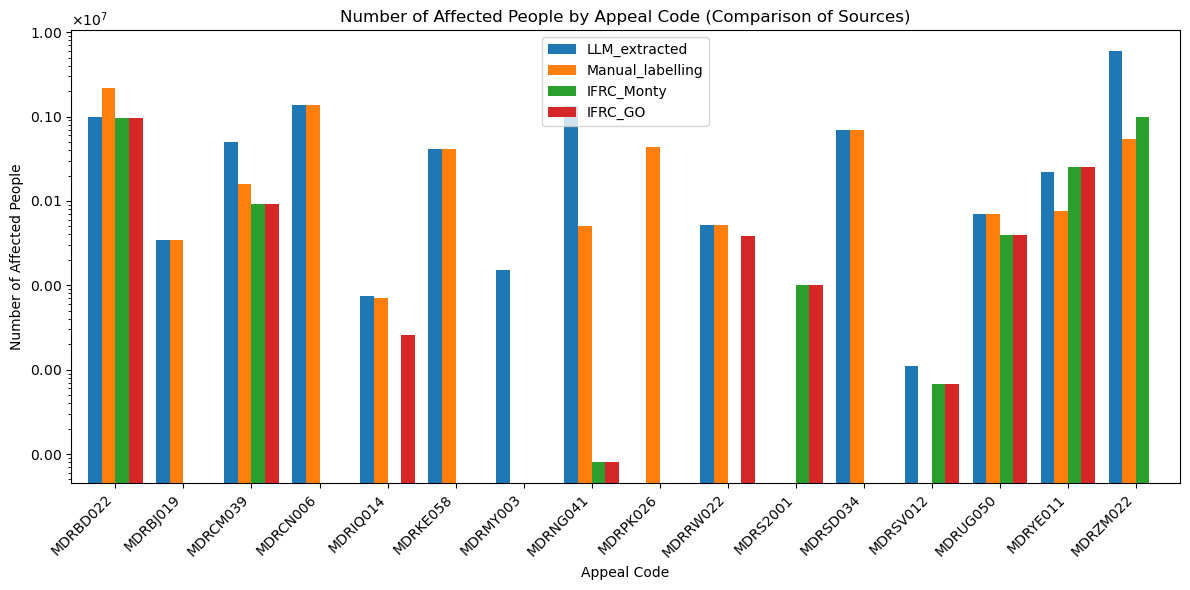

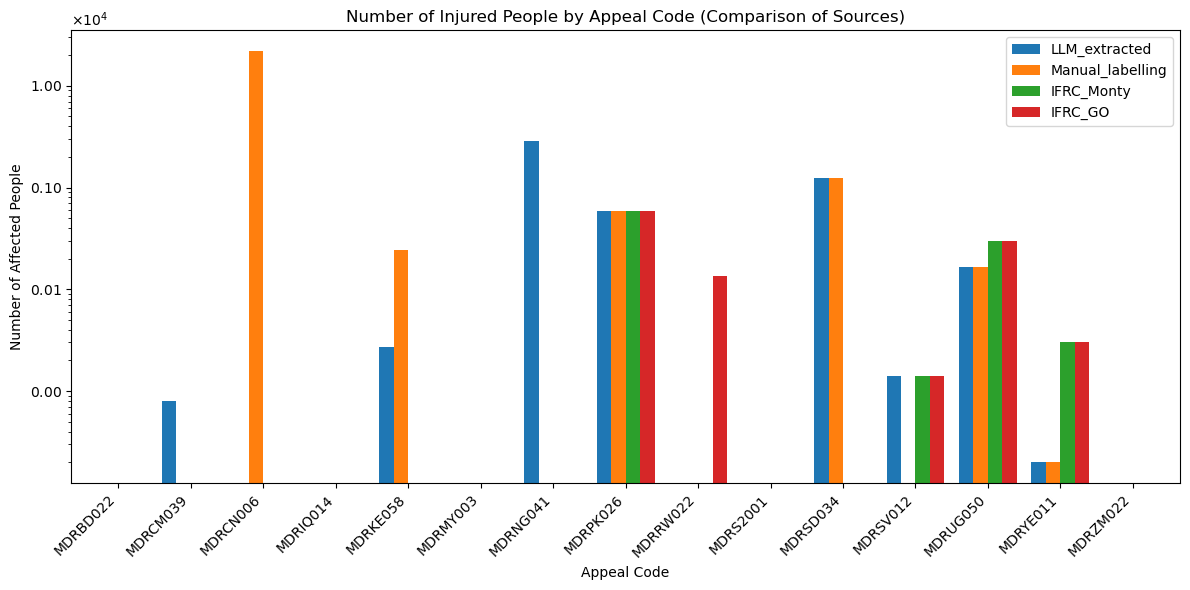

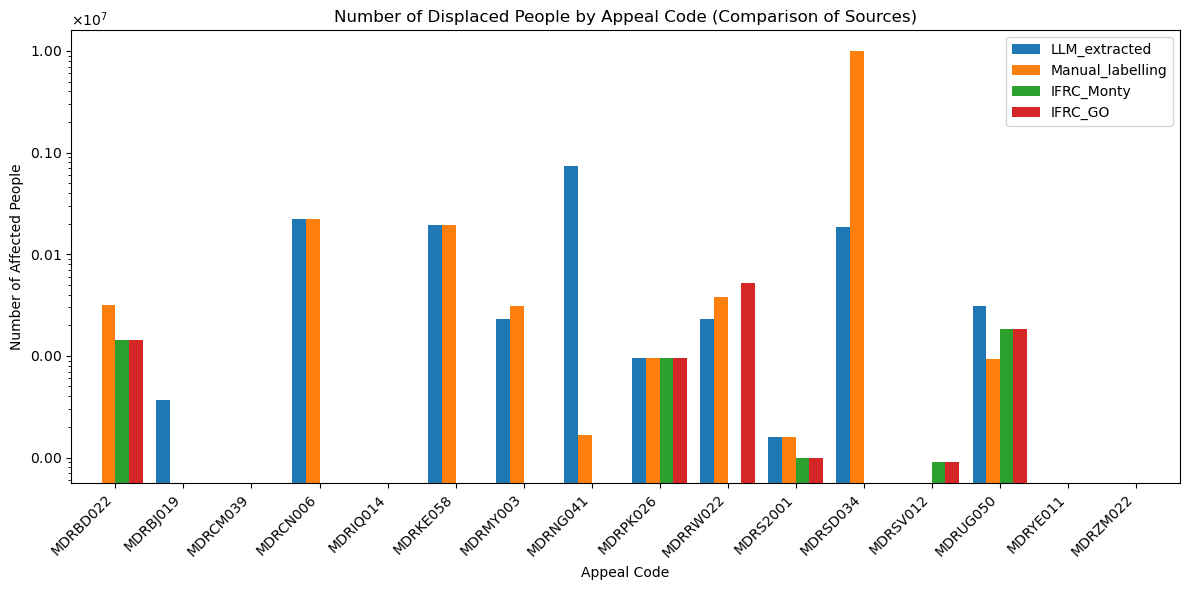

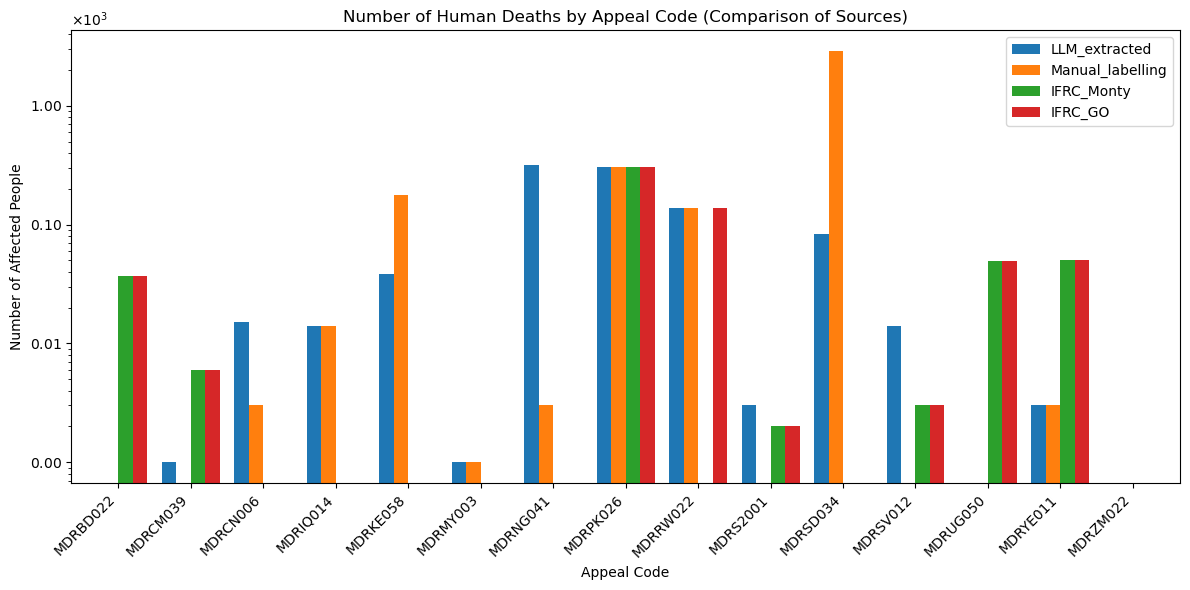

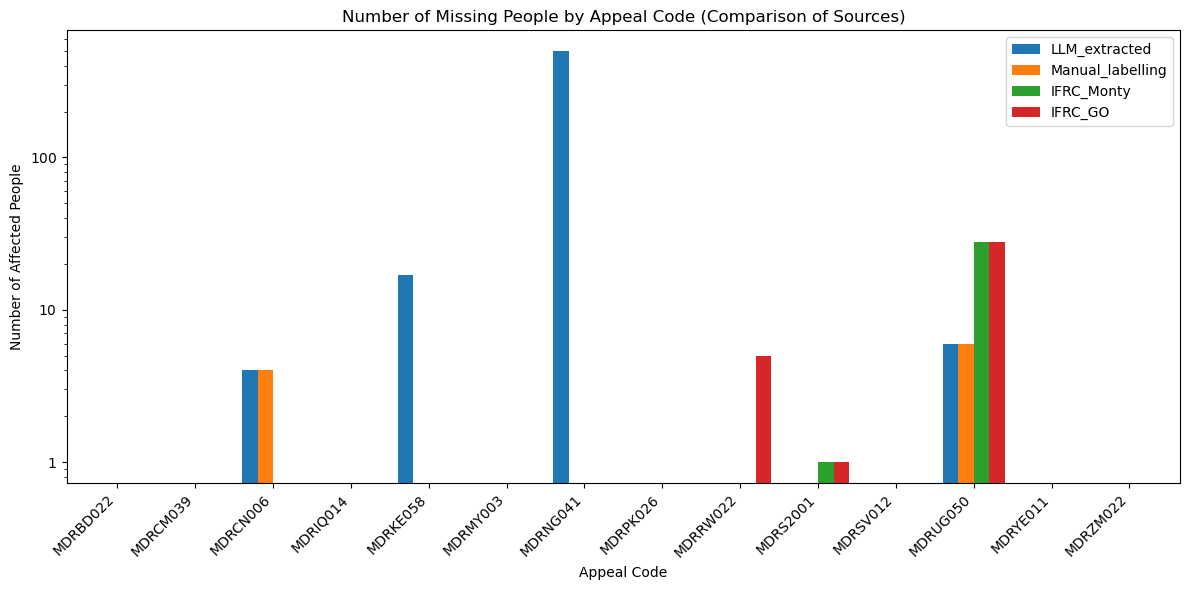

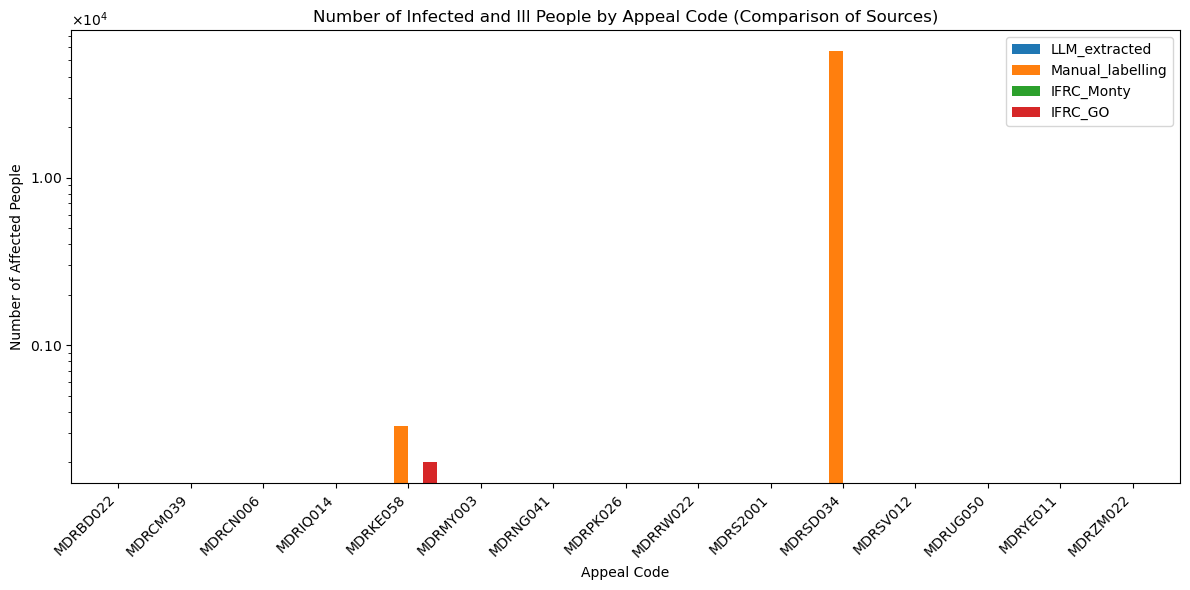

In [33]:
impact_list = list(mapping_impact_type.keys())
for impactType in  impact_list: 
    df_plot_data = plot_affected_people(df_llm_geo_grp, df_labelled_geo_grp, df_ifrc_monty, df_ifrc_go, df_llm_geo_grp.appealCode.unique(), impactType)

In [37]:
from pystac_client import Client
#get catalog
monty_api = "https://montandon-eoapi-stage.ifrc.org/stac/"
catalog = Client.open(monty_api)#"https://montandon-eoapi-stage.ifrc.org/stac/api")

In [100]:
# def safe_item_collection(search):
#     """Fetch all items from a pystac_client.ItemSearch safely, page by page."""
#     all_items = list(search.items())   # stream + collect into list
#     return ItemCollection(all_items)

from pystac import ItemCollection
def safe_item_collection(search, max_items=None):
    """Fetch items page by page and combine into one ItemCollection.
    If max_items is set, stop after collecting that many.
    """
    all_items = []
    count = 0
    
    for item in search.items():
        all_items.append(item)
        count += 1
        if max_items and count >= max_items:
            break
    return ItemCollection(all_items)


def emdat_to_dataframe_full(search, max_items=None):
    """Fetch all items from a pystac_client.ItemSearch into a DataFrame, including all properties and geometry."""
    rows = []
    count = 0
    
    for item in search.items():
        row = dict(item.properties)  # copy all properties
        row["id"] = item.id          # add item id
        row["geometry"] = item.geometry  # add geometry
        rows.append(row)
        count += 1
        if max_items and count >= max_items:
            break
    
    return pd.DataFrame(rows)

In [ ]:
event_collection_all_emdat_search = catalog.search(collections=["emdat-events"])#.item_collection()
# event_collection_all_emdat = safe_item_collection(event_collection_all_emdat_search, max_items=500)
df_emdat = emdat_to_dataframe_full(event_collection_all_emdat_search, max_items=500)

In [101]:
impact_collection_all_emdat_search = catalog.search(collections=["emdat-events"])#.item_collection()
# impact_collection_all_emdat = safe_item_collection(impact_collection_all_emdat_search, max_items=500)
df_impact_emdat = emdat_to_dataframe_full(impact_collection_all_emdat_search, max_items=500)

In [102]:
df_impact_emdat.to_csv(DATA_EXTERNAL_SOURCE + 'emdat_monty_subset.csv')

In [103]:
df_impact_emdat.head()

,roles,title,datetime,description,end_datetime,monty:etl_id,monty:corr_id,start_datetime,monty:hazard_codes,monty:country_codes,monty:episode_number,id,geometry
0,"[source, event]",Road in India,2025-07-29T00:00:00Z,"Road in Deoghar (Jharkhand state), India of Ju...",2025-07-29T00:00:00Z,5217e777-a13a-4c98-9ab4-7c90c0b6c743,20250729-IND-TEC-TRA-ROA-ROA-1-GCDB,2025-07-29T00:00:00Z,[tec-tra-roa-roa],[IND],1,emdat-event-2025-0633-IND,"{'type': 'MultiPolygon', 'coordinates': [[[[78..."
1,"[source, event]",Ground movement in Guatemala,2025-07-29T00:00:00Z,Earthquake in Jerez municipality (Jutiapa depa...,2025-07-29T00:00:00Z,d2f134cb-bfae-4133-80f5-a2feedb77155,20250729-GTM-NAT-GEO-EAR-GRO-1-GCDB,2025-07-29T00:00:00Z,[nat-geo-ear-gro],[GTM],1,emdat-event-2025-0621-GTM,"{'type': 'Point', 'coordinates': [-89.883, 14...."
2,"[source, event]",Flood (General) in Romania,2025-07-28T00:00:00Z,"Flood in Suceava, Neamt counties, Romania of J...",2025-07-28T00:00:00Z,eb2d0a9f-807d-47c4-8015-621ef17a4788,20250728-ROU-NAT-HYD-FLO-FLO-1-GCDB,2025-07-28T00:00:00Z,[nat-hyd-flo-flo],[ROU],1,emdat-event-2025-0632-ROU,"{'type': 'Polygon', 'coordinates': [[[28.21484..."
3,"[source, event]",Road in China,2025-07-27T00:00:00Z,"Road in Shanxi, China of July 2025",2025-07-27T00:00:00Z,ee6c3cd1-a4d4-476e-a439-4029f0806155,20250727-CHN-TEC-TRA-ROA-ROA-1-GCDB,2025-07-27T00:00:00Z,[tec-tra-roa-roa],[CHN],1,emdat-event-2025-0630-CHN,"{'type': 'MultiPolygon', 'coordinates': [[[[13..."
4,"[source, event]",Flash flood in Nigeria,2025-07-27T00:00:00Z,"Flood in Yola (Adamawa State), Nigeria of July...",2025-07-27T00:00:00Z,06c90484-caf3-4a33-a2e5-0c3973ac0574,20250727-NGA-NAT-HYD-FLO-FLA-1-GCDB,2025-07-27T00:00:00Z,[nat-hyd-flo-fla],[NGA],1,emdat-event-2025-0626-NGA,"{'type': 'MultiPolygon', 'coordinates': [[[[13..."


# Matching with Desinventar

In [6]:
df_desinventar = pd.read_csv(DATA_EXTERNAL_SOURCE + 'desinventar_monty_subset.csv', encoding='utf-8')

C:\Users\lhasbini\AppData\Local\Temp\ipykernel_17664\2500045001.py:1: DtypeWarning: Columns (13) have mixed types. Specify dtype option on import or set low_memory=False.
  df_desinventar = pd.read_csv(DATA_EXTERNAL_SOURCE + 'desinventar_monty_subset.csv', encoding='utf-8')


In [7]:
# Look for common monty:corr_id
common = df_desinventar.merge(df_ifrc_monty, on='monty:corr_id')
print("DESINVENTAR, Common Corr_id : ", common['monty:corr_id'].nunique())

NameError: name 'df_ifrc_monty' is not defined

In [ ]:
df_desinventar.head()

,Unnamed: 0,geometry,roles,title,datetime,description,end_datetime,monty:etl_id,monty:corr_id,start_datetime,monty:hazard_codes,monty:country_codes,monty:episode_number,keywords,id,impact_type,impact_value,impact_category,impact_estimate_type
0,0,POLYGON ((9.957970999999999 14.195972999999999...,"source, impact",DROUGHT in KOUTCHARAM on 2202-01-01 00:00:00+0...,2202-01-01T00:00:00Z,DROUGHT in KOUTCHARAM: None,2202-01-01T00:00:00Z,fb928a9c-2043-4436-8ae6-3137cb93a76c,22020101-NER-NAT-CLI-DRO-DRO-1-GCDB,2202-01-01T00:00:00Z,"MH0035, nat-met-dro-dro",NER,1,NaN,desinventar-impact-28012-lost_cattle,missing,160.0,cattle,primary
1,1,POLYGON ((9.957970999999999 14.195972999999999...,"source, impact",DROUGHT in KOUTCHARAM on 2202-01-01 00:00:00+0...,2202-01-01T00:00:00Z,DROUGHT in KOUTCHARAM: None,2202-01-01T00:00:00Z,78acf739-7422-4d00-b249-249f654ce187,22020101-NER-NAT-CLI-DRO-DRO-1-GCDB,2202-01-01T00:00:00Z,"MH0035, nat-met-dro-dro",NER,1,NaN,desinventar-impact-28012-damages_in_crops_ha,damaged,160.0,crops,primary
2,2,"POLYGON ((2.774996 14.295993999999999, 2.83699...","source, impact",FLOOD in BOUKOU HIMA on 2034-08-13 00:00:00+00...,2034-08-13T00:00:00Z,FLOOD in BOUKOU HIMA: None,2034-08-13T00:00:00Z,893c8b8a-3a24-4bf5-b1c8-b990de11f7b1,20340813-NER-NAT-HYD-FLO-FLO-1-GCDB,2034-08-13T00:00:00Z,nat-hyd-flo-flo,NER,1,NaN,desinventar-impact-43078-houses_destroyed,destroyed,33.0,buildings,primary
3,3,"POLYGON ((2.774996 14.295993999999999, 2.83699...","source, impact",FLOOD in BOUKOU HIMA on 2034-08-13 00:00:00+00...,2034-08-13T00:00:00Z,FLOOD in BOUKOU HIMA: None,2034-08-13T00:00:00Z,939c349d-37a8-46e7-aab5-d095bbd26412,20340813-NER-NAT-HYD-FLO-FLO-1-GCDB,2034-08-13T00:00:00Z,nat-hyd-flo-flo,NER,1,NaN,desinventar-impact-43078-houses_damaged,damaged,1.0,buildings,primary
4,4,"POLYGON ((3.5338209999999997 14.517564, 3.5298...","source, impact",FLOOD in DOGO BANZA BABA on 2027-07-27 00:00:0...,2027-07-27T00:00:00Z,FLOOD in DOGO BANZA BABA: None,2027-07-27T00:00:00Z,de620bd6-268f-48da-b0ff-b9372b2b540c,20270727-NER-NAT-HYD-FLO-FLO-1-GCDB,2027-07-27T00:00:00Z,nat-hyd-flo-flo,NER,1,NaN,desinventar-impact-42773-houses_destroyed,destroyed,2.0,buildings,primary


In [8]:
# Function to map hazard names to main types
def map_to_main_type(name):
    for main_type, names in hazard_mapping_emdat.items():
        if name in names:
            return main_type
    return None  # fallback if not found

# Process a single row
def get_hazard(codes_str):
    codes = [c.strip() for c in codes_str.split(',')]  # split by comma
    for c in codes:
        hazard_name = emdat_undrr_to_name.get(c)
        if hazard_name:
            main_type = map_to_main_type(hazard_name)
            if main_type:
                return main_type
    return None

# Apply to dataframe
df_desinventar['hazards_desinventar'] = df_desinventar['monty:hazard_codes'].apply(get_hazard)

# Convert to datetime
# df_desinventar['start_datetime'] = pd.to_datetime(df_desinventar['start_datetime'], utc=True)
df_desinventar['startYear'] = df_desinventar['start_datetime'].str[:4].astype(int)

In [17]:
df_desinventar['startYear'].unique()

array([2202, 2034, 2027, 2025, 2024, 2023, 2022, 2021, 2020, 2019, 2018,
       2017, 2016, 2015, 2014, 2013, 2012, 2011, 2010, 2009, 2008, 2007,
       2006, 2005, 2004, 2003, 2002, 2001, 2000, 1999, 1998, 1997, 1996,
       1995, 1994, 1993, 1992, 1991, 1990, 1989, 1988, 1987, 1986, 1985,
       1984, 1983, 1982, 1981, 1980, 1979, 1978, 1977, 1976, 1975, 1974,
       1973, 1972, 1971, 1970, 1969, 1968, 1967, 1966, 1965, 1964, 1963,
       1962, 1961, 1960, 1959, 1958, 1957, 1956, 1955, 1954, 1953, 1952,
       1951, 1950, 1949, 1948, 1947, 1946, 1945, 1944, 1943, 1942, 1941,
       1940, 1939, 1938, 1937, 1936, 1935, 1934, 1933, 1932, 1931, 1930,
       1929, 1928, 1927, 1926, 1925, 1924, 1923, 1922, 1921, 1920, 1919,
       1918, 1917, 1916, 1915, 1914, 1913, 1912, 1911, 1910, 1909, 1908,
       1907, 1906, 1905, 1903, 1902, 1901, 1900, 1899, 1898, 1897, 1895,
       1894, 1893, 1892, 1891, 1890, 1888, 1887, 1886, 1884, 1881, 1880,
       1879, 1878, 1877, 1876, 1874, 1871, 1869, 18

In [9]:
# Look for unique hazard
## Rename emdat columns 
df_desinventar_match = df_desinventar.copy().rename({'monty:country_codes' : 'country_iso3_kw'}, axis=1)

# First merge on country + startYear
df_llm_desinventar = df_desinventar_match.merge(df_llm_geo_grp, on=['country_iso3_kw','startYear'], how='inner')

# Keep only rows where Disaster Type is inside hazards list
df_llm_desinventar = df_llm_desinventar[
    df_llm_desinventar.apply(lambda row: row["hazards_desinventar"] in row["hazards"], axis=1)
].reset_index(drop=True)

# df_llm_desinventar = df_llm_desinventar[
#     df_llm_desinventar.apply(lambda row: row["country_emdat"] in row["country"], axis=1)
# ].reset_index(drop=True)

In [16]:
df_desinventar_match.merge(df_llm_geo_grp, on=['country_iso3_kw','startYear'], how='inner')

,Unnamed: 0,geometry_x,roles,title,datetime,description,end_datetime,monty:etl_id,monty:corr_id,start_datetime,...,gaul2_code,locationLowestAdmin,geocoding_country_flag,geocoding_osm_flag,locationLowestAdminNum,endYear,endMonth,impactValueMin,impactValueMax,endDay
0,95,MULTIPOLYGON (((39.28044608690616 -4.624805480...,"source, impact",FIRE in riverside slums Lungalunga on 2024-12-...,2024-12-18T00:00:00Z,FIRE in riverside slums Lungalunga: None,2024-12-18T00:00:00Z,18acded9-6234-4434-9a5a-267b51dcef0c,20241218-KEN-NAT-CLI-WIL-LAN-1-GCDB,2024-12-18T00:00:00Z,...,[None],ADM_0,1,0,0.0,NaN,NaN,NaN,NaN,NaN
1,110,POLYGON ((37.44628256288074 -0.537631172974921...,"source, impact",FIRE in Gitondo village on 2024-11-24 00:00:00...,2024-11-24T00:00:00Z,FIRE in Gitondo village: None,2024-11-24T00:00:00Z,e1f9a4c7-7408-43d6-a3fe-ef8d28eeaf25,20241124-KEN-NAT-CLI-WIL-LAN-1-GCDB,2024-11-24T00:00:00Z,...,[None],ADM_0,1,0,0.0,NaN,NaN,NaN,NaN,NaN
2,111,POLYGON ((34.68086659538113 0.1255223137555823...,"source, impact",FIRE in Cheptulu on 2024-11-23 00:00:00+00:00 ...,2024-11-23T00:00:00Z,FIRE in Cheptulu: None,2024-11-23T00:00:00Z,75b9e139-7636-4bfb-9ee5-3b096a26c4ce,20241123-KEN-NAT-CLI-WIL-LAN-1-GCDB,2024-11-23T00:00:00Z,...,[None],ADM_0,1,0,0.0,NaN,NaN,NaN,NaN,NaN
3,120,MULTIPOLYGON (((36.410736882010426 -0.77174112...,"source, impact","FIRE in Sirodit village, Nessuit, Njoro - Naku...",2024-10-30T00:00:00Z,"FIRE in Sirodit village, Nessuit, Njoro - Naku...",2024-10-30T00:00:00Z,ffc918ef-5d8d-41c3-b99b-685951663f3a,20241030-KEN-NAT-CLI-WIL-LAN-1-GCDB,2024-10-30T00:00:00Z,...,[None],ADM_0,1,0,0.0,NaN,NaN,NaN,NaN,NaN
4,121,POLYGON ((37.47661116909091 -0.595766704629173...,"source, impact","FIRE in Kithangu village, Manyatta - Embu Nort...",2024-10-27T00:00:00Z,"FIRE in Kithangu village, Manyatta - Embu Nort...",2024-10-27T00:00:00Z,9505edd3-fa99-4e76-b66a-29f3f0aa42b4,20241027-KEN-NAT-CLI-WIL-LAN-1-GCDB,2024-10-27T00:00:00Z,...,[None],ADM_0,1,0,0.0,NaN,NaN,NaN,NaN,NaN


In [14]:
df_llm_desinventar

,Unnamed: 0,geometry_x,roles,title,datetime,description,end_datetime,monty:etl_id,monty:corr_id,start_datetime,...,gaul2_code,locationLowestAdmin,geocoding_country_flag,geocoding_osm_flag,locationLowestAdminNum,endYear,endMonth,impactValueMin,impactValueMax,endDay


In [12]:
appeal_disno_counts = (
    df_llm_desinventar
    .groupby("appealCode")["monty:corr_id"]
    .nunique()
    .reset_index(name="unique_corr_id_count")
)

In [13]:
appeal_disno_counts

,appealCode,unique_corr_id_count


In [127]:
df_desinventar["monty:hazard_codes"].unique()

array(['MH0035, nat-met-dro-dro', 'nat-hyd-flo-flo', 'nat-met-sto-sto',
       'nat-bio-epi-dis', 'GH0007, nat-hyd-mmw-lan',
       'EN0013, nat-cli-wil-wil', 'OT', 'MH0060, nat-met-sto-sto',
       'MH0006, nat-hyd-flo-fla', 'nat-cli-wil-for',
       'MH0059, nat-met-sto-tor', 'tec-mis-col-col',
       'MH0057, nat-met-tro-tro', 'tec-mis-exp-exp',
       'MH0036, nat-met-sto-hai', 'GH0001, nat-geo-ear-grd',
       'VO, nat-geo-vol-vol', 'MH0003, nat-met-sto-sto',
       'MH0043, nat-met-ext-sev', 'MH0029, nat-geo-ear-tsu',
       'nat-hyd-flo-fla, MH0006', 'nat-met-sto-sto, MH0060',
       'nat-hyd-mmw-lan, GH0007', 'tec-mis-col-col, TL0005',
       'nat-met-sto-sto, MH0002', 'nat-cli-wil-wil, EN0013',
       'nat-geo-vol-vol, VO', 'tec-ind-che-che',
       'nat-met-sto-hai, MH0036', 'MH0050, nat-hyd-mmw-ava',
       'nat-geo-ear-grd, GH0001', 'nat-met-ext-sev, MH0043',
       'nat-met-sto-sur, MH0027', 'nat-met-sto-tro, MH0057',
       'MH0027, nat-met-sto-sur', 'nat-met-dro-dro, MH0

# Matching with EM-DAT

In [120]:
df_emdat = pd.read_csv(DATA_EXTERNAL_SOURCE + 'emdat_monty_subset.csv', encoding='utf-8')

In [121]:
# Look for common monty:corr_id
common = df_emdat.merge(df_ifrc_monty, on='monty:corr_id')
print("EMDAT, Common Corr_id : ", common['monty:corr_id'].nunique())

EMDAT, Common Corr_id :  2


In [99]:
df_ifrc_monty.loc[(df_ifrc_monty["monty:country_codes"]=="KGZ")]

,Unnamed: 0,geometry,roles,title,datetime,description,end_datetime,monty:etl_id,monty:corr_id,start_datetime,monty:hazard_codes,monty:country_codes,monty:episode_number,id,impact_type,impact_value,impact_category,impact_estimate_type,appealCode
12,12,"POLYGON ((80.23403000000008 42.19622000000004,...","source, impact",KGZ: Epidemic - 03-2025 - Measles outbreak,2025-03-13 00:00:00+00:00,"With 4169 suspected cases, including 3,739 mea...",2025-03-13T00:00:00+00:00,a64f29fa-e569-41ee-8383-cc496d49f2b8,20250313-KGZ-NAT-BIO-EPI-DIS-1-GCDB,2025-03-13T00:00:00+00:00,nat-bio-epi-dis,KGZ,1,ifrcevent-impact--7450-assisted,assisted,2,people,primary,MDRKG021
167,167,"POLYGON ((80.23403000000008 42.19622000000004,...","source, impact",KGZ: Flood - 04-2024 - Floods Kyrgyzstan,2024-04-20 00:00:00+00:00,"<p class=""MsoNormal"" style=""margin-bottom: 0cm...",2024-04-20T00:00:00+00:00,3ef2c3d6-e571-41f0-95e3-59b1b648ca29,20240420-KGZ-NAT-HYD-FLO-FLO-1-GCDB,2024-04-20T00:00:00+00:00,FL,KGZ,1,ifrcevent-impact--6955-assisted,assisted,20,people,primary,MDRKG019
168,168,"POLYGON ((80.23403000000008 42.19622000000004,...","source, impact",KGZ: Flood - 04-2024 - Floods Kyrgyzstan,2024-04-20 00:00:00+00:00,"<p class=""MsoNormal"" style=""margin-bottom: 0cm...",2024-04-20T00:00:00+00:00,4200fa4f-a0d0-4e8e-8192-e6fc6f25a832,20240420-KGZ-NAT-HYD-FLO-FLO-1-GCDB,2024-04-20T00:00:00+00:00,FL,KGZ,1,ifrcevent-impact--6955-affected_total,Affected People,6821,people,primary,MDRKG019
296,296,"POLYGON ((80.23403000000008 42.19622000000004,...","source, impact",KGZ: Flood - 2023-08 - Mudflows Kyrgyzstan Iss...,2023-08-02 00:00:00+00:00,<p>According to the Ministry of Emergency Situ...,2023-08-02T00:00:00+00:00,02327f99-e9a0-48d4-9a3b-df387528a472,20230802-KGZ-NAT-HYD-FLO-FLO-1-GCDB,2023-08-02T00:00:00+00:00,FL,KGZ,1,ifrcevent-impact--6589-assisted,assisted,145,people,primary,MDRKG017
297,297,"POLYGON ((80.23403000000008 42.19622000000004,...","source, impact",KGZ: Flood - 2023-08 - Mudflows Kyrgyzstan Iss...,2023-08-02 00:00:00+00:00,<p>According to the Ministry of Emergency Situ...,2023-08-02T00:00:00+00:00,cead89da-b7ac-4f4f-b110-4cade9cefefd,20230802-KGZ-NAT-HYD-FLO-FLO-1-GCDB,2023-08-02T00:00:00+00:00,FL,KGZ,1,ifrcevent-impact--6589-affected_total,Affected People,580,people,primary,MDRKG017


In [92]:
df_ifrc_monty.loc[df_ifrc_monty["monty:corr_id"]=="20241027-ESP-FL-1-GCDB"]

,Unnamed: 0,geometry,roles,title,datetime,description,end_datetime,monty:etl_id,monty:corr_id,start_datetime,monty:hazard_codes,monty:country_codes,monty:episode_number,id,impact_type,impact_value,impact_category,impact_estimate_type,appealCode


In [ ]:
tail_events = df_emdat["monty:corr_id"]

In [90]:
for corr in tail_events : 
    # print(corr)
    if not df_ifrc_monty.loc[df_ifrc_monty["monty:corr_id"]==corr].empty :
        print(df_ifrc_monty.loc[df_ifrc_monty["monty:corr_id"]==corr])

In [61]:
items_list = list(event_collection_all_emdat)  # convert to a list
first_item = items_list[0]  # get the first item
# first_10_item = items_list[:10]  # get the first item
print(first_item)

<Item id=emdat-event-2025-0633-IND>


In [63]:
first_item.to_dict().keys()

dict_keys(['type', 'stac_version', 'stac_extensions', 'id', 'geometry', 'bbox', 'properties', 'links', 'assets', 'collection'])

In [74]:
first_item.to_dict()["properties"]

{'roles': ['source', 'event'],
 'title': 'Road in India',
 'datetime': '2025-07-29T00:00:00Z',
 'description': 'Road in Deoghar (Jharkhand state), India of July 2025',
 'end_datetime': '2025-07-29T00:00:00Z',
 'monty:etl_id': '5217e777-a13a-4c98-9ab4-7c90c0b6c743',
 'monty:corr_id': '20250729-IND-TEC-TRA-ROA-ROA-1-GCDB',
 'start_datetime': '2025-07-29T00:00:00Z',
 'monty:hazard_codes': ['tec-tra-roa-roa'],
 'monty:country_codes': ['IND'],
 'monty:episode_number': 1}

In [47]:
for item in event_collection_all_emdat_search.items():
    print(item.id, item.properties.get("title"))

emdat-event-2025-0633-IND Road in India
emdat-event-2025-0621-GTM Ground movement in Guatemala
emdat-event-2025-0632-ROU Flood (General) in Romania
emdat-event-2025-0630-CHN Road in China
emdat-event-2025-0626-NGA Flash flood in Nigeria
emdat-event-2025-0617-CIV Road in Côte d’Ivoire
emdat-event-2025-0616-NGA Water in Nigeria
emdat-event-2025-0593-MMR Storm (Tropical cyclone) in Myanmar of July 2025
emdat-event-2025-0614-PER Road in Peru
emdat-event-2025-0613-RUS Explosion (Miscellaneous) in Russian Federation of July 2025
emdat-event-2025-0611-VNM Road in Viet Nam
emdat-event-2025-0610-RUS Air in Russian Federation of July 2025
emdat-event-2025-0623-CHN Flood (General) in China
emdat-event-2025-0608-CYP Wildfire (General) in Cyprus
emdat-event-2025-0593-VNM Storm (Tropical cyclone) in Viet Nam of July 2025
emdat-event-2025-0596-PAK Flood (General) in Pakistan
emdat-event-2025-0595-BGD Air in Bangladesh of July 2025
emdat-event-2025-0598-THA Severe weather in Thailand
emdat-event-2025-

KeyboardInterrupt: 

In [ ]:
event_collection_all_emdat = event_collection_all_emdat_search.item_collection()

In [ ]:
items_emdat = catalog.search(collections=["emdat-impacts"], limit=100).item_collection()

In [ ]:
event_collection_all_emdat.

In [46]:
event_collection_all_emdat = event_collection_all_emdat_search.item_collection()

APIError: <html>
<head><title>502 Bad Gateway</title></head>
<body>
<center><h1>502 Bad Gateway</h1></center>
<hr><center>nginx</center>
</body>
</html>


In [34]:
#Open EM-DAT 
df_em_dat = pd.read_excel(DATA_EXTERNAL_SOURCE + 'public_emdat_custom_request_2025-08-19.xlsx')
# df_em_dat = df_em_dat[["DisNo.", "Disaster Type", 'Country', 'Subregion', 'Region', 'Location', 
#                        'Start Year', 'Start Month', 'Start Day', 'End Year', 'End Month', 'End Day',
#                        'Total Deaths', 'No. Injured', 'No. Affected', 'No. Homeless',
#                        'Total Affected', "Reconstruction Costs ('000 US$)",
#                        "Reconstruction Costs, Adjusted ('000 US$)", "Insured Damage ('000 US$)", "Insured Damage, Adjusted ('000 US$)",
#                        "Total Damage ('000 US$)", "Total Damage, Adjusted ('000 US$)"]]

In [35]:
df_em_dat.columns

Index(['DisNo.', 'Historic', 'Classification Key', 'Disaster Group',
       'Disaster Subgroup', 'Disaster Type', 'Disaster Subtype',
       'External IDs', 'Event Name', 'ISO', 'Country', 'Subregion', 'Region',
       'Location', 'Origin', 'Associated Types', 'OFDA/BHA Response', 'Appeal',
       'Declaration', 'AID Contribution ('000 US$)', 'Magnitude',
       'Magnitude Scale', 'Latitude', 'Longitude', 'River Basin', 'Start Year',
       'Start Month', 'Start Day', 'End Year', 'End Month', 'End Day',
       'Total Deaths', 'No. Injured', 'No. Affected', 'No. Homeless',
       'Total Affected', 'Reconstruction Costs ('000 US$)',
       'Reconstruction Costs, Adjusted ('000 US$)',
       'Insured Damage ('000 US$)', 'Insured Damage, Adjusted ('000 US$)',
       'Total Damage ('000 US$)', 'Total Damage, Adjusted ('000 US$)', 'CPI',
       'Admin Units', 'Entry Date', 'Last Update'],
      dtype='object')

In [36]:
df_em_dat.iloc[0]

DisNo.                                                  1900-0003-USA
Historic                                                          Yes
Classification Key                                    nat-met-sto-tro
Disaster Group                                                Natural
Disaster Subgroup                                      Meteorological
Disaster Type                                                   Storm
Disaster Subtype                                     Tropical cyclone
External IDs                                                      NaN
Event Name                                                        NaN
ISO                                                               USA
Country                                      United States of America
Subregion                                            Northern America
Region                                                       Americas
Location                                            Galveston (Texas)
Origin              

In [75]:
# Map hazards to emdat hazards 
reverse_mapping = {}
for main, subs in hazard_mapping_emdat.items():
    for s in subs:
        reverse_mapping[s.lower()] = main   # lowercase for robustness

# --- For df_em_dat (single hazard per row) ---
df_em_dat["Disaster Type"] = df_em_dat["Disaster Type"].str.lower().map(reverse_mapping)

# --- For df_llm (list of hazards per row) ---
def map_hazard_list(hazard_list):
    mapped = []
    for h in hazard_list:
        h_low = h.lower()
        if h_low in reverse_mapping:
            mapped.append(reverse_mapping[h_low])
    return list(set(mapped))  # remove duplicates

df_llm["hazards"] = df_llm["hazards"].apply(map_hazard_list)

In [76]:
## Rename emdat columns 
df_em_dat = df_em_dat.rename({'Country' : 'country_emdat', 'Start Year' : 'startYear'}, axis=1)

# First merge on country + startYear
df_llm_em_dat = df_em_dat.merge(df_llm, on=['startYear'], how='inner')

# Keep only rows where Disaster Type is inside hazards list
df_llm_em_dat = df_llm_em_dat[
    df_llm_em_dat.apply(lambda row: row["Disaster Type"] in row["hazards"], axis=1)
].reset_index(drop=True)

df_llm_em_dat = df_llm_em_dat[
    df_llm_em_dat.apply(lambda row: row["country_emdat"] in row["country"], axis=1)
].reset_index(drop=True)

In [77]:
df_llm_em_dat.head()

,DisNo.,Historic,Classification Key,Disaster Group,Disaster Subgroup,Disaster Type,Disaster Subtype,External IDs,Event Name,ISO,...,reportLink,disasterType,nathaz_text,country_iso3,country_iso3_kw,impactSubtype_orig,hazards_reclass,impactValueOrig,impactUnitOrig,unit_type
0,2017-0224-MYS,No,nat-hyd-flo-flo,Natural,Hydrological,Flood,Flood (General),DFO:4443,NaN,MYS,...,https://adore.ifrc.org/Download.aspx?FileId=17...,Flood,['a. situation analysis description of the dis...,NaN,MYS,Displaced People,['Flood'],23000.0,people,other
1,2017-0224-MYS,No,nat-hyd-flo-flo,Natural,Hydrological,Flood,Flood (General),DFO:4443,NaN,MYS,...,https://adore.ifrc.org/Download.aspx?FileId=17...,Flood,['a. situation analysis description of the dis...,NaN,MYS,Human Deaths,['Flood'],1.0,person,other
2,2017-0224-MYS,No,nat-hyd-flo-flo,Natural,Hydrological,Flood,Flood (General),DFO:4443,NaN,MYS,...,https://adore.ifrc.org/Download.aspx?FileId=17...,Flood,['a. situation analysis description of the dis...,NaN,MYS,Human Health and Wellbeing,['Flood'],NaN,NaN,other
3,2017-0224-MYS,No,nat-hyd-flo-flo,Natural,Hydrological,Flood,Flood (General),DFO:4443,NaN,MYS,...,https://adore.ifrc.org/Download.aspx?FileId=17...,Flood,['a. situation analysis description of the dis...,NaN,MYS,Access to Healthcare,['Flood'],NaN,NaN,other
4,2017-0224-MYS,No,nat-hyd-flo-flo,Natural,Hydrological,Flood,Flood (General),DFO:4443,NaN,MYS,...,https://adore.ifrc.org/Download.aspx?FileId=17...,Flood,['a. situation analysis description of the dis...,NaN,MYS,"Water, Sanitation, and Hygiene Infrastructure",['Flood'],3000.0,hygiene kits,other


In [78]:
appeal_disno_counts = (
    df_llm_em_dat
    .groupby("appealCode")["DisNo."]
    .nunique()
    .reset_index(name="unique_DisNo_count")
)

In [79]:
appeal_disno_counts

,appealCode,unique_DisNo_count
0,MDRBD022,4
1,MDRBJ019,1
2,MDRCM039,2
3,MDRCN006,8
4,MDRIQ014,3
5,MDRKE058,4
6,MDRMY003,3
7,MDRNG041,2
8,MDRPK026,2
9,MDRRW022,1


In [80]:
DisNo_MDRBD022=df_llm_em_dat.loc[df_llm_em_dat.appealCode=="MDRCN006"]["DisNo."].unique()

In [81]:
df_llm.loc[df_llm.appealCode=="MDRCN006"]

,impactSubtype,impactValue,impactUnit,impactValuePrecision,country,location,startYear,startMonth,startDay,endYear,...,reportLink,disasterType,nathaz_text,country_iso3,country_iso3_kw,impactSubtype_orig,hazards_reclass,impactValueOrig,impactUnitOrig,unit_type
55,Affected People,1381000.0,people,exact,[China],"[Sichuan, Gansu]",2018.0,7.0,7.0,NaN,...,https://adore.ifrc.org/Download.aspx?FileId=23...,Flood,['dref operation operation n° mdrcn006 date of...,NaN,CHN,Affected People,['Flood'],1381000.0,people,other
56,Human Deaths,15.0,people,exact,[China],"[Sichuan, Gansu]",2018.0,7.0,7.0,NaN,...,https://adore.ifrc.org/Download.aspx?FileId=23...,Flood,['dref operation operation n° mdrcn006 date of...,NaN,CHN,Human Deaths,['Flood'],15.0,people,other
57,Displaced People,222000.0,people,exact,[China],[Sichuan],2018.0,7.0,7.0,NaN,...,https://adore.ifrc.org/Download.aspx?FileId=23...,Flood,['dref operation operation n° mdrcn006 date of...,NaN,CHN,Displaced People,['Flood'],222000.0,people,other
58,Missing People,4.0,people,exact,[China],[Gansu],2018.0,7.0,10.0,NaN,...,https://adore.ifrc.org/Download.aspx?FileId=23...,Flood,['dref operation operation n° mdrcn006 date of...,NaN,CHN,Missing People,['Flood'],4.0,people,other
59,Residential Buildings,900.0,homes,exact,[China],[Sichuan],2018.0,7.0,7.0,NaN,...,https://adore.ifrc.org/Download.aspx?FileId=23...,Flood,['dref operation operation n° mdrcn006 date of...,NaN,CHN,Residential Buildings,['Flood'],900.0,houses,other
60,Residential Buildings,2300.0,homes,exact,[China],[Gansu],2018.0,7.0,10.0,NaN,...,https://adore.ifrc.org/Download.aspx?FileId=23...,Flood,['dref operation operation n° mdrcn006 date of...,NaN,CHN,Residential Buildings,['Flood'],2300.0,houses,other
61,Other Economic and Livelihood Impacts,792000000.0,CHF,exact,[China],[Sichuan],2018.0,7.0,7.0,NaN,...,https://adore.ifrc.org/Download.aspx?FileId=23...,Flood,['dref operation operation n° mdrcn006 date of...,NaN,CHN,Economy and Market,['Flood'],792000000.0,CHF,other
62,Other Economic and Livelihood Impacts,538000000.0,CHF,exact,[China],[Gansu],2018.0,7.0,10.0,NaN,...,https://adore.ifrc.org/Download.aspx?FileId=23...,Flood,['dref operation operation n° mdrcn006 date of...,NaN,CHN,Economy and Market,['Flood'],538000000.0,CHF,other
63,Crop Production and Forestry,369.0,km**2 of undefined crop production and forestry,exact,[China],[Sichuan],2018.0,7.0,7.0,NaN,...,https://adore.ifrc.org/Download.aspx?FileId=23...,Flood,['dref operation operation n° mdrcn006 date of...,NaN,CHN,Crop Production and Forestry,['Flood'],36900.0,hectares,km**2
64,Human Health and Wellbeing,NaN,unknown,NaN,[China],"[Sichuan, Gansu]",2018.0,7.0,7.0,NaN,...,https://adore.ifrc.org/Download.aspx?FileId=23...,Flood,['dref operation operation n° mdrcn006 date of...,NaN,CHN,Human Health and Wellbeing,['Flood'],NaN,NaN,other


In [91]:
df_em_dat.loc[df_em_dat['DisNo.'].isin(DisNo_MDRBD022)][["DisNo.", "Disaster Type", 'country_emdat', 'Subregion', 'Region', 'Location', 
                       'startYear', 'Start Month', 'Start Day', 'End Year', 'End Month', 'End Day',
                       'Total Deaths', 'No. Injured', 'No. Affected', 'No. Homeless',
                       'Total Affected', 'Admin Units', 'Entry Date', 'Last Update']]

,DisNo.,Disaster Type,country_emdat,Subregion,Region,Location,startYear,Start Month,Start Day,End Year,End Month,End Day,Total Deaths,No. Injured,No. Affected,No. Homeless,Total Affected,Admin Units,Entry Date,Last Update
14457,2018-0159-CHN,Flood,China,Eastern Asia,Asia,Guangxi Zhuang Autonomous,2018,5.0,7.0,2018,5.0,16.0,5.0,NaN,70000.0,NaN,70000.0,"[{""adm1_code"":904,""adm1_name"":""Guangxi Zhuangz...",2018-05-23,2023-09-25
14479,2018-0198-CHN,Flood,China,Eastern Asia,Asia,"Sichuan, Gansu, Chongqing, Hubei, Jiangsu, Gui...",2018,5.0,5.0,2018,7.0,31.0,112.0,NaN,450000.0,NaN,450000.0,"[{""adm1_code"":898,""adm1_name"":""Anhui Sheng""},{...",2018-07-19,2023-09-25
14492,2018-0210-CHN,Flood,China,Eastern Asia,Asia,"Jiangxi, Hebei, Shanxi, Jiangsu, Shandong, Hen...",2018,5.0,7.0,2018,5.0,30.0,77.0,NaN,225000.0,NaN,225000.0,"[{""adm1_code"":900,""adm1_name"":""Chongqing Shi""}...",2018-07-20,2023-09-25
14493,2018-0211-CHN,Flood,China,Eastern Asia,Asia,"Fujian, Guangdong, Guangxi",2018,5.0,7.0,2018,5.0,14.0,2.0,NaN,6000.0,NaN,6000.0,"[{""adm1_code"":901,""adm1_name"":""Fujian Sheng""},...",2018-07-20,2023-09-25
14531,2018-0250-CHN,Flood,China,Eastern Asia,Asia,"Deyang, Mianyang, Guangyuan prefectures (Sichu...",2018,7.0,7.0,2018,7.0,7.0,3.0,NaN,1381000.0,NaN,1381000.0,"[{""adm2_code"":13259,""adm2_name"":""Deyang""},{""ad...",2018-07-27,2023-09-25
14532,2018-0252-CHN,Flood,China,Eastern Asia,Asia,"Tianshui, Zhangye, Pingliang (Gansu province)",2018,7.0,10.0,2018,7.0,11.0,16.0,NaN,1519000.0,NaN,1519000.0,"[{""adm2_code"":13018,""adm2_name"":""Tianshui""},{""...",2018-07-27,2023-09-25
14548,2018-0282-CHN,Flood,China,Eastern Asia,Asia,NaN,2018,6.0,28.0,2018,7.0,5.0,11.0,NaN,36000.0,NaN,36000.0,NaN,2018-08-09,2023-09-25
14597,2018-0369-CHN,Flood,China,Eastern Asia,Asia,NaN,2018,8.0,29.0,2018,9.0,5.0,18.0,NaN,11400.0,NaN,11400.0,NaN,2018-10-11,2023-09-25


In [ ]:
df_em_dat.loc[df_em_dat['DisNo.'].isin(DisNo_MDRBD022)][["DisNo.", "Disaster Type", 'country_emdat', 'Subregion', 'Region', 'Location', 
                       'startYear', 'Start Month', 'Start Day', 'End Year', 'End Month', 'End Day',
                       'Total Deaths', 'No. Injured', 'No. Affected', 'No. Homeless',
                       'Total Affected', 'Admin Units', 'Entry Date', 'Last Update']]